SETUP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

EDA

In [2]:
df=pd.read_csv("weatherAUS.csv.zip")
df.shape

(145460, 23)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [4]:
# 16 numerical data types and 7 categorical data types

In [5]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [6]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [7]:
#Spliting target variable from remaining features
x=df.drop('RainTomorrow',axis=1)
y=df['RainTomorrow']
num_df=df.select_dtypes(include=['number'])
cat_df=df.select_dtypes(exclude=['number'])

In [8]:
miss_num=num_df.isnull().mean()*100
miss_num.sort_values(ascending=False)

Sunshine         48.009762
Evaporation      43.166506
Cloud3pm         40.807095
Cloud9am         38.421559
Pressure9am      10.356799
Pressure3pm      10.331363
WindGustSpeed     7.055548
Humidity3pm       3.098446
Temp3pm           2.481094
Rainfall          2.241853
WindSpeed3pm      2.105046
Humidity9am       1.824557
WindSpeed9am      1.214767
Temp9am           1.214767
MinTemp           1.020899
MaxTemp           0.866905
dtype: float64

In [9]:
#Sunshine evaporation cloud3pm cloud9am have the highest missing data percentage
y.isnull().sum()

np.int64(3267)

In [10]:
#Our data set is imbalanced
y.value_counts()

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

In [11]:
#Filled missing values of target variable with its mode
y=y.fillna(y.mode()[0])

In [12]:
y=y.map({'No': 0, 'Yes': 1})

In [13]:
x[['Sunshine','Evaporation','Cloud3pm','Cloud9am']].corrwith(y)

Sunshine      -0.443561
Evaporation   -0.117719
Cloud3pm       0.377607
Cloud9am       0.313025
dtype: float64

In [14]:
#Dropping evaporation as it has highest missing % data and lowest corr with the target variable
x=x.drop('Evaporation',axis=1)

In [15]:
#Chronologically sorting x dataset wrt time,location and acc sorting target var
x['Date']=pd.to_datetime(x['Date'])
x=x.sort_values(by=['Location','Date']).reset_index(drop=True)
original_sorted_indices = df.sort_values(by=['Location', 'Date']).index
y_aligned = y.loc[original_sorted_indices].reset_index(drop=True)

In [16]:
interp_cols = ['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm','Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm','Cloud9am', 'Cloud3pm', 'Sunshine']
clean_chunks = []
#Grouping weather data based on location and setting index as date for time based interpolation
for location, group in x.groupby('Location'):
    group = group.set_index('Date')
    group[interp_cols] = group[interp_cols].interpolate(method='time', limit_direction='both')
    group = group.reset_index()
    clean_chunks.append(group)
x = pd.concat(clean_chunks, ignore_index=True)

In [17]:
x[interp_cols].isnull().sum()

MinTemp              0
MaxTemp              0
Temp9am              0
Temp3pm              0
WindGustSpeed     6079
WindSpeed9am         0
WindSpeed3pm         0
Humidity9am          0
Humidity3pm          0
Pressure9am      12119
Pressure3pm      12119
Cloud9am         34967
Cloud3pm         34967
Sunshine         53169
dtype: int64

In [18]:
#Using median for remaining data to tackle outliers, which may be present in such a weather dataset
for col in interp_cols:
    if x[col].isnull().sum() > 0:
        x[col] = x[col].fillna(x[col].median())
if 'Rainfall' in x.columns:
    x['Rainfall'] = x['Rainfall'].fillna(x['Rainfall'].median())

In [19]:
#Filling categorical colns missing values with their mode
cat_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']
for col in cat_cols:
    if x[col].isnull().sum() > 0:
        x[col] = x[col].fillna(x[col].mode()[0])

In [20]:
x.isnull().sum()

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
dtype: int64

In [21]:
num_df=x.select_dtypes(include=['number'])
cat_df=x.select_dtypes(exclude=['number'])

In [22]:
corr_mat=num_df.corr()

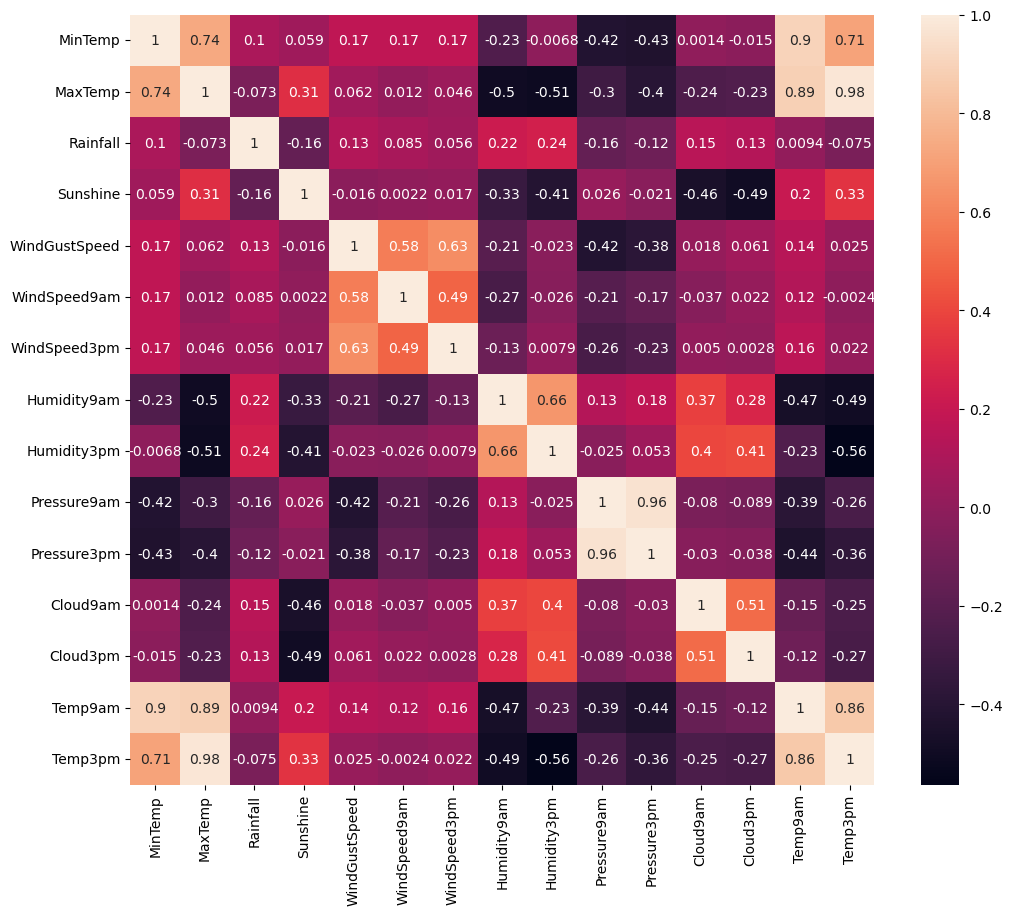

In [23]:
plt.figure(figsize=(12,10))
sns.heatmap(corr_mat,annot=True)
plt.show()

In [24]:
#Checked for multicollinearity bw num features

array([[<Axes: title={'center': 'MinTemp'}>,
        <Axes: title={'center': 'MaxTemp'}>,
        <Axes: title={'center': 'Rainfall'}>,
        <Axes: title={'center': 'Sunshine'}>],
       [<Axes: title={'center': 'WindGustSpeed'}>,
        <Axes: title={'center': 'WindSpeed9am'}>,
        <Axes: title={'center': 'WindSpeed3pm'}>,
        <Axes: title={'center': 'Humidity9am'}>],
       [<Axes: title={'center': 'Humidity3pm'}>,
        <Axes: title={'center': 'Pressure9am'}>,
        <Axes: title={'center': 'Pressure3pm'}>,
        <Axes: title={'center': 'Cloud9am'}>],
       [<Axes: title={'center': 'Cloud3pm'}>,
        <Axes: title={'center': 'Temp9am'}>,
        <Axes: title={'center': 'Temp3pm'}>, <Axes: >]], dtype=object)

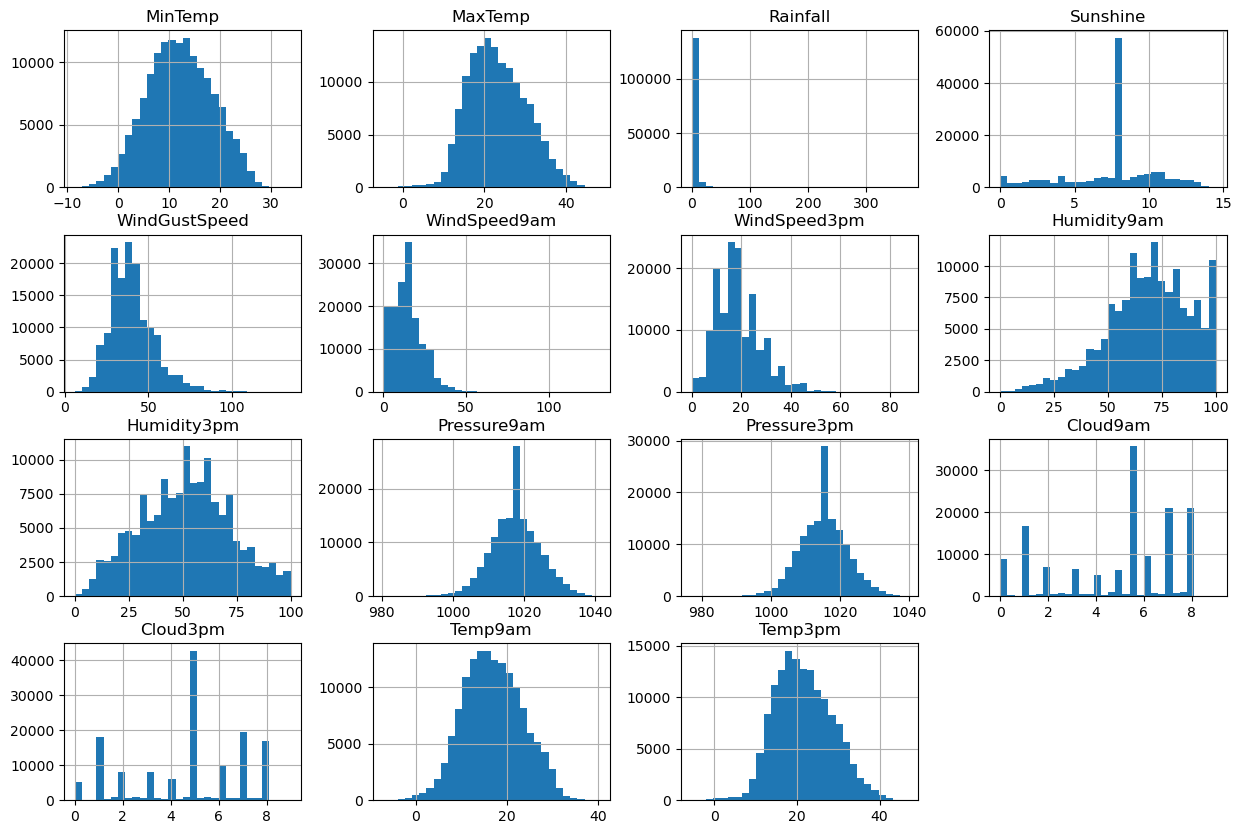

In [25]:
#Checking distribution of num features for skewness
num_df.hist(bins=30, figsize=(15, 10))

In [26]:
cat_df.count()

Date           145460
Location       145460
WindGustDir    145460
WindDir9am     145460
WindDir3pm     145460
RainToday      145460
dtype: int64

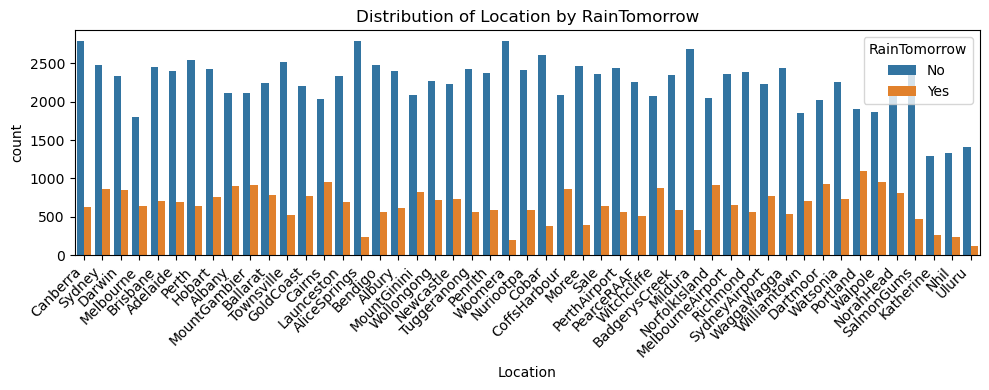

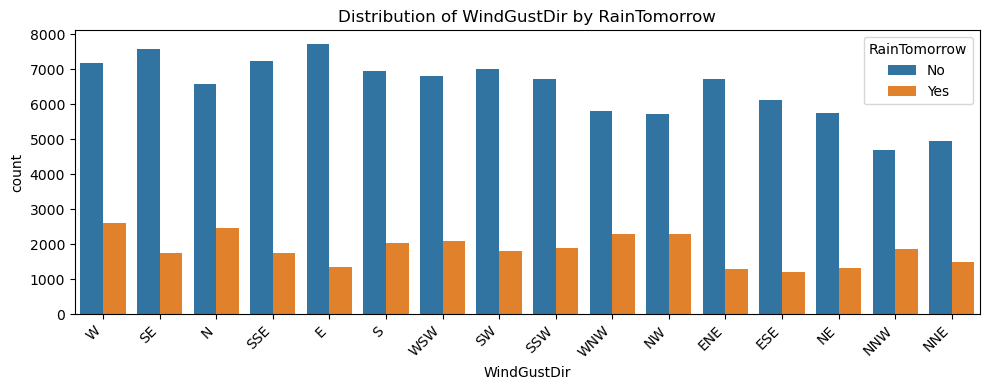

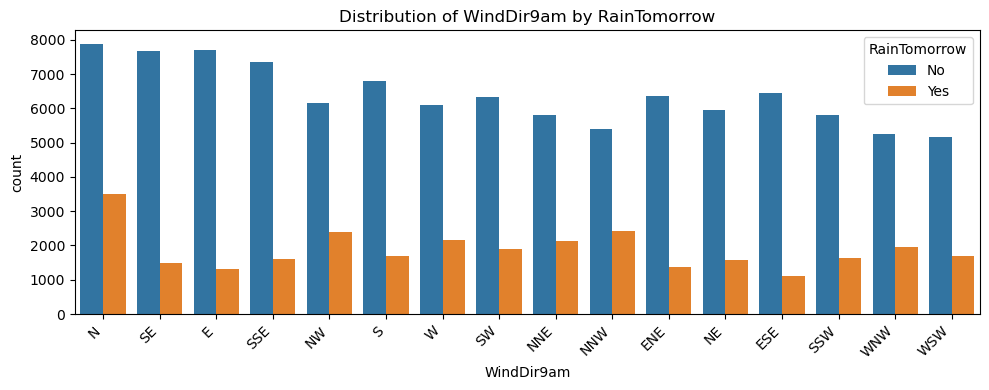

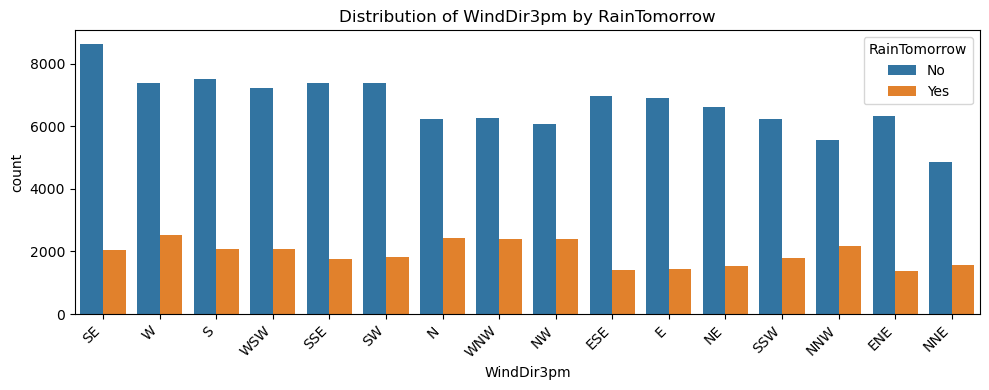

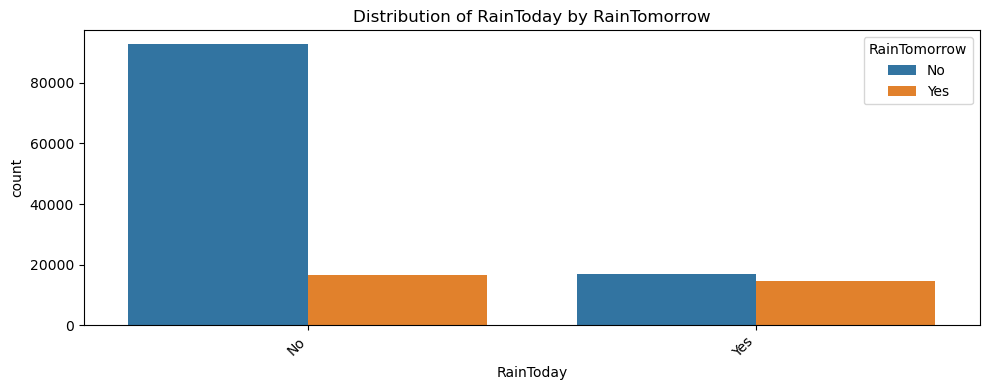

In [27]:
#Analyzing cat features with target var
cat_vars = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']
for col in cat_vars:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, hue='RainTomorrow', order=df[col].value_counts().index)
    plt.title(f'Distribution of {col} by RainTomorrow')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [28]:
df[cat_vars].nunique()

Location       49
WindGustDir    16
WindDir9am     16
WindDir3pm     16
RainToday       2
dtype: int64

In [29]:
df['Location'].value_counts()

Location
Canberra            3436
Sydney              3344
Darwin              3193
Melbourne           3193
Brisbane            3193
Adelaide            3193
Perth               3193
Hobart              3193
Albany              3040
MountGambier        3040
Ballarat            3040
Townsville          3040
GoldCoast           3040
Cairns              3040
Launceston          3040
AliceSprings        3040
Bendigo             3040
Albury              3040
MountGinini         3040
Wollongong          3040
Newcastle           3039
Tuggeranong         3039
Penrith             3039
Woomera             3009
Nuriootpa           3009
Cobar               3009
CoffsHarbour        3009
Moree               3009
Sale                3009
PerthAirport        3009
PearceRAAF          3009
Witchcliffe         3009
BadgerysCreek       3009
Mildura             3009
NorfolkIsland       3009
MelbourneAirport    3009
Richmond            3009
SydneyAirport       3009
WaggaWagga          3009
Williamtown     

In [30]:
#Applying cyclical encoding to months using sin and cos
x['Month'] = x['Date'].dt.month
x['Month_sin'] = np.sin(2 * np.pi * x['Month'] / 12)
x['Month_cos'] = np.cos(2 * np.pi * x['Month'] / 12)

In [31]:
#Feature engineering
x['TempRange'] = x['MaxTemp'] - x['MinTemp']
x['HumidityChange'] = x['Humidity3pm'] - x['Humidity9am']
x['PressureTrend'] = x['Pressure3pm'] - x['Pressure9am']

In [32]:
#Based on obs from multicollinearity and feature engineering 
cols_to_drop = ['MinTemp', 'Temp9am', 'MaxTemp', 'Cloud9am', 'Date']
X_numerical = x.select_dtypes(include=['number']).drop(columns=cols_to_drop, errors='ignore')

In [33]:
X_numerical.corrwith(y_aligned)

Rainfall          0.233877
Sunshine         -0.299984
WindGustSpeed     0.219542
WindSpeed9am      0.086951
WindSpeed3pm      0.084372
Humidity9am       0.250837
Humidity3pm       0.429619
Pressure9am      -0.229271
Pressure3pm      -0.211789
Cloud3pm          0.271326
Temp3pm          -0.187631
Month             0.007674
Month_sin        -0.019005
Month_cos        -0.045749
TempRange        -0.328578
HumidityChange    0.251355
PressureTrend     0.070463
dtype: float64

In [34]:
#Transforming skewed cols
skewed_cols = ['Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']
for col in skewed_cols:
    if col in X_numerical.columns:
        X_numerical[col] = np.log1p(X_numerical[col])

In [35]:
X_categorical = x[['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']].copy()
X_full = pd.concat([X_numerical, X_categorical], axis=1)

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_full, y_aligned, test_size=0.2, random_state=42, stratify=y_aligned)

In [37]:
#As location has 49 unique values, we use target encoding to get its historical likelihood of raining instead of using normal encoding which might confuse the model
location_means = y_train.groupby(X_train['Location']).mean()
global_mean = y_train.mean()
X_train['Location_encoded'] = X_train['Location'].map(location_means).fillna(global_mean)
X_test['Location_encoded'] = X_test['Location'].map(location_means).fillna(global_mean)

In [38]:
#Ordinal encoding
wind_directions = ['N','NNE','NE','ENE','E','ESE','SE','SSE','S','SSW','SW','WSW','W','WNW','NW','NNW']
wind_map = {val: i for i, val in enumerate(wind_directions)}
wind_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm']

In [39]:
#Cyclical endoing
for col in wind_cols:
    train_idx = X_train[col].map(wind_map)
    test_idx = X_test[col].map(wind_map)
    
    X_train[f'{col}_sin'] = np.sin(2 * np.pi * train_idx / 16)
    X_train[f'{col}_cos'] = np.cos(2 * np.pi * train_idx / 16)
    X_test[f'{col}_sin'] = np.sin(2 * np.pi * test_idx / 16)
    X_test[f'{col}_cos'] = np.cos(2 * np.pi * test_idx / 16)

In [40]:
#Binary encoding
X_train['RainToday_encoded'] = X_train['RainToday'].map({'No': 0, 'Yes': 1}).fillna(0)
X_test['RainToday_encoded'] = X_test['RainToday'].map({'No': 0, 'Yes': 1}).fillna(0)

In [41]:
drop_text_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']
X_train_final = X_train.drop(columns=drop_text_cols)
X_test_final = X_test.drop(columns=drop_text_cols)

In [42]:
X_train_final.fillna(0, inplace=True)
X_test_final.fillna(0, inplace=True)

In [43]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_final.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_final.columns)
X_train_scaled.head()

,Rainfall,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud3pm,...,HumidityChange,PressureTrend,Location_encoded,WindGustDir_sin,WindGustDir_cos,WindDir9am_sin,WindDir9am_cos,WindDir3pm_sin,WindDir3pm_cos,RainToday_encoded
0,-0.528936,0.126341,0.368445,0.638395,0.040657,-0.885487,-1.559737,-0.011192,-0.006781,0.144898,...,-0.942203,0.015721,-0.945717,1.489361,0.065431,1.470176,-0.115099,0.991668,-0.914607,-0.529223
1,-0.528936,0.695020,0.224957,-0.453283,0.321519,1.211030,0.169931,-0.159016,-0.575722,-0.709892,...,-1.184278,-1.431235,0.004618,1.489361,0.065431,-1.405923,0.403248,1.403489,0.095887,-0.529223
2,-0.528936,-0.643048,-1.137847,-0.612374,-0.417236,1.315856,0.314070,-0.188581,-0.515833,0.999688,...,-1.123759,-1.121173,-0.353235,1.489361,0.065431,0.547320,1.136302,1.403489,0.095887,-0.529223
3,-0.528936,0.126341,-1.913010,-2.930751,-0.417236,0.844140,-0.262486,0.550540,0.966408,1.427083,...,-1.305316,1.411001,-0.229823,0.644261,-1.301618,-0.024772,1.239408,0.535513,-1.224387,-0.529223
4,-0.528936,-0.375435,-0.426812,0.213449,0.040657,-0.466183,-0.646857,0.905317,0.547188,-1.564682,...,-0.276495,-1.276204,-2.184940,1.489361,0.065431,1.032316,-1.072881,1.296460,0.642762,-0.529223


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

#Initialize the Logistic Regression Model, class_weight='balanced' handles our data imbalance perfectly
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

#Train the model on your scaled training data
model.fit(X_train_scaled, y_train)

#Predict on the scaled test data
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

=== CONFUSION MATRIX ===
[[17910  4807]
 [ 1517  4858]]

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.92      0.79      0.85     22717
           1       0.50      0.76      0.61      6375

    accuracy                           0.78     29092
   macro avg       0.71      0.78      0.73     29092
weighted avg       0.83      0.78      0.80     29092


ROC-AUC Score: 0.8571


In [45]:
#Get the feature weights
importance_df = pd.DataFrame({'Feature': X_train_final.columns,'Coefficient': model.coef_[0]})

In [46]:
importance_df['Abs_Coefficient'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])

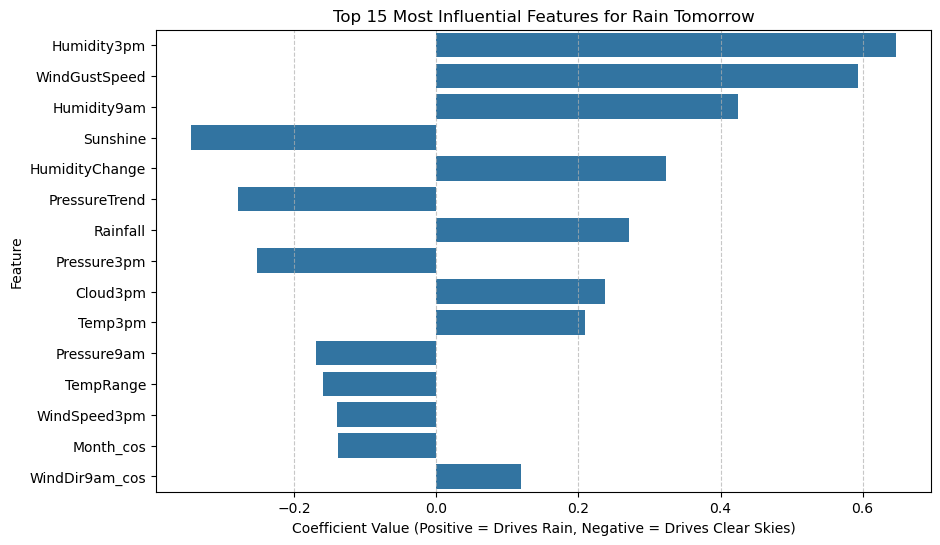

In [47]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Coefficient', y='Feature')
plt.title('Top 15 Most Influential Features for Rain Tomorrow')
plt.xlabel('Coefficient Value (Positive = Drives Rain, Negative = Drives Clear Skies)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [48]:
import joblib
import os

In [49]:
os.makedirs('artifacts', exist_ok=True)
joblib.dump(model, 'artifacts/logistic_rain_model.pkl')
joblib.dump(scaler, 'artifacts/scaler.pkl')
joblib.dump(location_means, 'artifacts/location_encoder.pkl')
joblib.dump(global_mean, 'artifacts/global_mean.pkl')

['artifacts/global_mean.pkl']

In [50]:
print(list(X_train_final.columns))

['Rainfall', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud3pm', 'Temp3pm', 'Month', 'Month_sin', 'Month_cos', 'TempRange', 'HumidityChange', 'PressureTrend', 'Location_encoded', 'WindGustDir_sin', 'WindGustDir_cos', 'WindDir9am_sin', 'WindDir9am_cos', 'WindDir3pm_sin', 'WindDir3pm_cos', 'RainToday_encoded']
